# Greenhouse Sensor Data Cleaning Project

In this notebook raw, messy sensor dataset (`raw_sensor_dataset.csv`) from a
greenhouse is taken and cleaned up step by step. The sensors record **temperature** and
**humidity**, and there's also a **fan_status** column that says whether
the ventilation fan was ON or OFF.

Real sensors are not perfect, so this raw dataset has a few problems on purpose:
some missing readings, some impossible/broken readings, and a handful of genuine
outliers. The goal of this notebook is to detect and handle all of that in a clear,
step-by-step way.


### **Step 1 — Load and inspect the dataset**

The required libraries are imported and the CSV file is loaded. The first few rows and basic information about the dataset are then checked to understand the data before starting the preprocessing steps.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)


In [2]:
df_raw = pd.read_csv("raw_sensor_dataset.csv")

print("Shape of the dataset (rows, columns):", df_raw.shape)
df_raw.head()


Shape of the dataset (rows, columns): (10000, 3)


,temperature,humidity,fan_status
0,29.0,60.2,ON
1,20.8,58.7,OFF
2,23.8,51.4,OFF
3,23.5,61.1,OFF
4,25.6,39.6,OFF


In [3]:
print("Column names:", list(df_raw.columns))
print()
print("Data types:")
print(df_raw.dtypes)


Column names: ['temperature', 'humidity', 'fan_status']

Data types:
temperature    float64
humidity       float64
fan_status         str
dtype: object


In [4]:
print("Missing values per column:")
print(df_raw.isna().sum())
print()
print("Percentage missing per column:")
print((df_raw.isna().mean() * 100).round(2))


Missing values per column:
temperature    200
humidity       200
fan_status       0
dtype: int64

Percentage missing per column:
temperature    2.0
humidity       2.0
fan_status     0.0
dtype: float64


So the dataset has 10,000 rows and 3 columns: `temperature`, `humidity` and
`fan_status`. Each row is one sensor reading taken in the greenhouse, along with
whether the fan was running at that moment. There are already some missing values
showing up in `temperature` and `humidity` — we'll deal with those soon.
Notice `fan_status` has no missing values, since it's the fan's actual recorded
state, not a raw analog sensor reading.


### **Step 2 — Set `fan_status` aside for now**

For the cleaning and outlier-detection steps, only the two numeric sensor columns — `temperature` and `humidity` — are used.

The `fan_status` column is kept separate because it acts as the **target**. It is determined by a rule based on temperature and humidity: the fan turns ON when any of these conditions exceeds the defined limit.

Using `fan_status` while cleaning or detecting outliers could introduce information about the target into the process. Therefore, `fan_status` is kept in `df_raw` but is not used in the next few steps. It will be added back to the processed data at the end.


In [5]:
sensor_cols = ["temperature", "humidity"]

# Keep the original fan_status safe on the side, matched to the row index,
# so we can reattach it later without ever using it for cleaning or Isolation Forest.
fan_status_original = df_raw["fan_status"].copy()

df_sensors = df_raw[sensor_cols].copy()
df_sensors.head()


,temperature,humidity
0,29.0,60.2
1,20.8,58.7
2,23.8,51.4
3,23.5,61.1
4,25.6,39.6


### **Step 3 — Find and flag invalid sensor values**

Before handling missing values, the sensor readings are checked for values that fall outside physically realistic ranges. These are treated as **sensor errors** rather than unusual but valid observations.

The following ranges are used:

* **Temperature:** 0°C to 45°C
* **Humidity:** 0% to 100%

Any value outside its respective range is replaced with the text `"error"`. This keeps the invalid reading identifiable while allowing it to be handled separately during the next preprocessing step.


In [6]:
valid_ranges = {
    "temperature": (0, 45),
    "humidity": (0, 100),
}

df_flagged = df_sensors.copy()
invalid_counts = {}

for col, (low, high) in valid_ranges.items():
    is_invalid = (df_flagged[col] < low) | (df_flagged[col] > high)
    invalid_counts[col] = int(is_invalid.sum())
    # switch the column to object dtype first so it can hold the "error" text
    # alongside the numbers (a plain float column can't store a string)
    df_flagged[col] = df_flagged[col].astype(object)
    df_flagged.loc[is_invalid, col] = "error"

print("Number of invalid values found per column:")
for col, count in invalid_counts.items():
    print(f"  {col}: {count}")


Number of invalid values found per column:
  temperature: 150
  humidity: 150


In [7]:
# a quick look at some of the rows that got flagged as "error"
error_mask = (df_flagged[sensor_cols] == "error").any(axis=1)
df_flagged[error_mask].head(10)


,temperature,humidity
65,18.7,error
70,19.8,error
84,error,75.8
97,error,77.8
98,error,51.4
133,error,58.3
191,31.9,error
216,error,76.1
269,19.9,error
287,error,41.1


### **Quick note on the difference between the three**

* **Invalid / error values** — readings that are physically impossible or clearly outside the defined sensor range, such as a temperature of 250°C or humidity of -40%. These usually indicate a sensor fault or transmission error.

* **Missing values** — readings that were not recorded at all and appear as blank or `NaN`. The actual value is unknown.

* **Outliers** — valid readings that are unusual compared to the rest of the data. They may represent rare but genuine conditions, so they cannot be identified simply by checking fixed ranges. Statistical methods such as **Isolation Forest** are used to detect them.


### **Step 4 — Handle missing values and `"error"` cells**

Both actual missing values (`NaN`) and `"error"` cells are treated as missing because neither provides a trustworthy sensor reading.

Two separate cleaned versions of the dataset are created so that the two approaches can be compared:

* **Method A — Median:** Missing values are replaced with the median value of their respective column.
* **Method B — Linear Interpolation:** Missing values are estimated using the values before and after them in the dataset.

The two methods are kept in separate dataframes so that the results of each approach remain independent.


In [8]:
# Replace "error" text with actual NaN so pandas treats it as missing,
# for both cleaning methods below.
df_for_cleaning = df_flagged.copy()
for col in sensor_cols:
    df_for_cleaning[col] = pd.to_numeric(df_for_cleaning[col], errors="coerce")

total_missing_now = df_for_cleaning[sensor_cols].isna().sum()
print("Total missing (original NaN + former 'error' cells) per column:")
print(total_missing_now)


Total missing (original NaN + former 'error' cells) per column:
temperature    350
humidity       350
dtype: int64


### Method A — Median imputation


In [9]:
df_median = df_for_cleaning.copy()

for col in sensor_cols:
    median_value = df_median[col].median()
    df_median[col] = df_median[col].fillna(median_value)
    print(f"{col}: filled missing values with median = {median_value}")

print()
print("Any missing values left?", df_median[sensor_cols].isna().sum().sum())
df_median.head(10)


temperature: filled missing values with median = 23.9
humidity: filled missing values with median = 55.150000000000006

Any missing values left? 0


,temperature,humidity
0,29.0,60.2
1,20.8,58.7
2,23.8,51.4
3,23.5,61.1
4,25.6,39.6
5,22.8,71.6
6,30.7,74.1
7,19.3,30.4
8,24.2,46.3
9,26.1,48.1


### **What is median imputation?**

Median imputation means finding the middle value of a column after sorting its valid values and using that value to fill the missing entries.

**Why it is useful:**
It is simple and fast, and unlike the mean, the median is not strongly affected by extreme values. This makes it a stable choice when the data contains some unusual readings.

**When it is a reasonable choice:**
Median imputation works well when missing values are scattered throughout the dataset and the order of the rows is not particularly important. It is also a useful simple approach for an initial data-cleaning step.

**When it is not suitable:**
It is less suitable when the data has a meaningful order, such as sensor readings collected over time. In such cases, the values immediately before and after a missing reading can provide useful information about what the missing value should be. Median imputation ignores this relationship and would replace different situations with the same overall median value.


### Method B — Linear interpolation


In [10]:
df_interpolated = df_for_cleaning.copy()

for col in sensor_cols:
    df_interpolated[col] = df_interpolated[col].interpolate(method="linear", limit_direction="both")

print("Any missing values left?", df_interpolated[sensor_cols].isna().sum().sum())
df_interpolated.head(10)


Any missing values left? 0


,temperature,humidity
0,29.0,60.2
1,20.8,58.7
2,23.8,51.4
3,23.5,61.1
4,25.6,39.6
5,22.8,71.6
6,30.7,74.1
7,19.3,30.4
8,24.2,46.3
9,26.1,48.1


### **What is linear interpolation?**

Linear interpolation estimates a missing value by looking at the valid reading immediately before the gap and the valid reading immediately after it. A straight line is assumed between these two values, and the missing values in between are estimated from that line.

**Why it can make sense for sensor data:**
Temperature and humidity usually change gradually over time rather than changing randomly from one reading to the next. For example, if the temperature is 24°C before a missing reading and 26°C after it, an estimated value around 25°C would be reasonable.

**When it is not suitable:**
Interpolation works best when the rows have a genuine sequential or time-based relationship. If the data has been shuffled or the row order does not represent time, the values before and after a gap do not provide meaningful information, making interpolation unreliable.

**What about a long continuous gap?**
Interpolation becomes less reliable when many consecutive readings are missing. For example, if around 10 readings are missing in a row, simply drawing a straight line between the two available readings may not represent what actually happened during that period. A sensor could have gone offline, or conditions could have changed because of a fan cycle or other environmental event.

In a real-world project, a long continuous gap may therefore be better excluded rather than filled using interpolation. In this dataset, no such long gap has been intentionally created; this is included only as an important limitation to keep in mind when using interpolation.


### **Step 5 — Detect outliers with Isolation Forest**

Once the missing and invalid values have been handled, the median-imputed dataset (`df_median`) is used to identify genuine outliers.

**How Isolation Forest works, in simple terms:**
Isolation Forest creates multiple random decision trees that repeatedly split the data into smaller groups. A normal data point is usually surrounded by similar points, so it takes more splits to separate it. An unusual point is more isolated from the rest of the data, so it can be separated in fewer splits.

In simple terms, the method asks: **“How easily can this observation be isolated from the others?”** If it can be isolated very quickly, it is more likely to be an outlier.

Only `temperature` and `humidity` are used for this step. The `fan_status` column is not included because it is the target and using it could introduce information leakage into the outlier-detection process.


In [11]:
X = df_median[sensor_cols]

# Contamination is set low on purpose, since we know the raw dataset only has
# a very small handful of genuine outliers mixed in.
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=RANDOM_SEED,
)

outlier_status = iso_forest.fit_predict(X)  # 1 = normal, -1 = outlier

df_median["outlier_status"] = outlier_status

n_normal = int((df_median["outlier_status"] == 1).sum())
n_outliers = int((df_median["outlier_status"] == -1).sum())
pct_outliers = round(100 * n_outliers / len(df_median), 3)

print("Normal observations:", n_normal)
print("Detected outliers:", n_outliers)
print(f"Percentage of outliers: {pct_outliers}%")


Normal observations: 9980
Detected outliers: 20
Percentage of outliers: 0.2%


In [12]:
df_median[df_median["outlier_status"] == -1][sensor_cols].head(20)


,temperature,humidity
707,38.7,18.9
1321,2.4,91.7
1559,38.7,18.1
1893,38.2,17.3
3082,40.0,17.3
4058,38.8,17.6
4286,2.5,90.4
4511,39.4,18.9
4548,39.1,95.0
6190,3.2,95.5


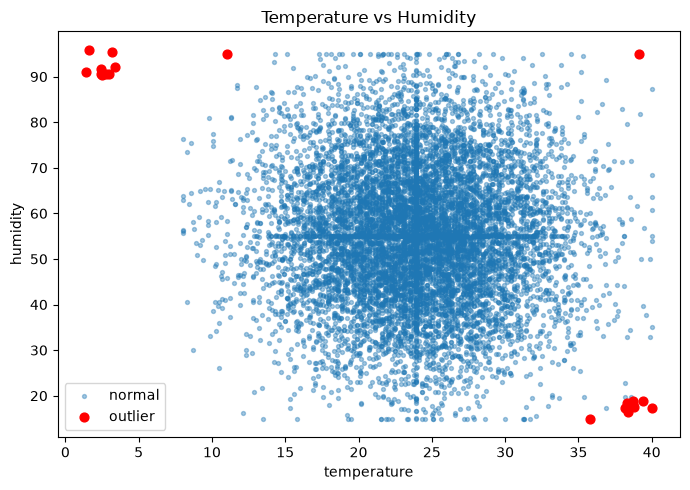

In [13]:
normal_points = df_median[df_median["outlier_status"] == 1]
outlier_points = df_median[df_median["outlier_status"] == -1]

plt.figure(figsize=(7, 5))
plt.scatter(normal_points["temperature"], normal_points["humidity"],
            s=8, alpha=0.4, label="normal")
plt.scatter(outlier_points["temperature"], outlier_points["humidity"],
            s=40, color="red", label="outlier")
plt.xlabel("temperature")
plt.ylabel("humidity")
plt.title("Temperature vs Humidity")
plt.legend()
plt.tight_layout()
plt.show()


### **Interpreting the outliers**

The detected outliers can be seen in red, separated from the main group of normal observations. Most of them represent unusual combinations such as **low temperature with high humidity**, or **high temperature with low humidity**.

Only a small number of observations were identified as outliers, which is consistent with the way the raw dataset was designed.


### **Step 6 — Build the final processed dataset**

The cleaned sensor readings, the Isolation Forest results, and the original `fan_status` column are combined into one final dataframe.

The columns in the final dataset represent:

* **`temperature` / `humidity`** — cleaned sensor readings, with missing and invalid values filled using median imputation.
* **`fan_status`** — the original ON/OFF fan state, added back after the cleaning and outlier-detection steps. It was not used during either process.
* **`outlier_status`** — the result from Isolation Forest. `1` represents a normal reading, while `-1` represents a reading flagged as an outlier.


In [14]:
processed_df = df_median[sensor_cols + ["outlier_status"]].copy()
processed_df["fan_status"] = fan_status_original.values
processed_df = processed_df[["temperature", "humidity", "fan_status", "outlier_status"]]

print("Final processed dataset shape:", processed_df.shape)
processed_df.head(10)


Final processed dataset shape: (10000, 4)


,temperature,humidity,fan_status,outlier_status
0,29.0,60.2,ON,1
1,20.8,58.7,OFF,1
2,23.8,51.4,OFF,1
3,23.5,61.1,OFF,1
4,25.6,39.6,OFF,1
5,22.8,71.6,ON,1
6,30.7,74.1,ON,1
7,19.3,30.4,OFF,1
8,24.2,46.3,OFF,1
9,26.1,48.1,OFF,1


In [15]:
processed_df["outlier_status"].value_counts()


outlier_status
 1    9980
-1      20
Name: count, dtype: int64

## Step 7 — Save the final dataset

save the final processed dataframe as a pickle file so it can be
reloaded later without redoing all the cleaning steps.


In [16]:
import os

output_filename = "processed_sensor_data.pkl"
processed_df.to_pickle(output_filename)

full_path = os.path.abspath(output_filename)

print("Processed dataset saved successfully as processed_sensor_data.pkl")
print("Saved at:", full_path)


Processed dataset saved successfully as processed_sensor_data.pkl
Saved at: /home/user/dataset-cleaning/processed_sensor_data.pkl
